# Evaluating Task 1 & Task 2 Summaries
**NLP Final Project — Dialectal Robustness**

Scores the LLM summaries from `make_ai_summaries.ipynb` (`summaries/task1_unconstrained.jsonl`,
`summaries/task2_constrained.jsonl`) and reports two things, matching the two research questions
in the project write-up:

- **Task 1 Results — Generation Bias.** When a model summarizes *without* being told which
  dialect to use, does it default toward a particular one regardless of the source article's
  dialect? Tested with **three independent dialect-detection classifiers** — Spelling Checker
  (`spelling_markers.py`), Posterior POS n-gram (`dialect_classifier.py`), and BERT
  (`bert_dialect_classifier.py`) — scored against `article_dialect` (the source article's dialect,
  a weak proxy label) and shown as a confusion matrix per classifier.
- **Task 2 Results — Evaluation Bias.** When a model *is* explicitly instructed to write in a
  given dialect (`target_dialect`, the reliable ground truth here), does summary quality differ
  by dialect? Tested with three quality metrics — LLM-as-a-judge score, BARTScore, and SummaC —
  shown as bar charts across each target dialect. (BERTScore was also tried; moved to a disabled
  "Dated" section at the bottom since it was slow and is superseded by the three above for the
  report.)

This reuses the exact prediction functions already written and reviewed in
`evaluate_on_summaries.py` (`predict_spelling`, `predict_pos_ngram`, `predict_bert`) rather than
re-implementing them, so all three classifiers here score every summary consistently with that
module.

Sample sizes grow as `make_ai_summaries.ipynb`'s batches complete — re-run this notebook any time
after generating more summaries.

In [174]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from helpers import evaluate_on_summaries as eval_lib
from helpers.dialect_classifier import build_classifier, DIALECTS
from helpers.bert_dialect_classifier import load_bert_classifier
from helpers.spelling_markers import load_spelling_markers

SUMMARIES_DIR = Path("./summaries")

# DIALECTS ("US"/"UK"/"AUS") stays the classifier/data vocabulary everywhere below — only the
# plot-facing labels (axis ticks, bar labels, confusion-matrix display labels) get the friendlier
# names, via this lookup.
DIALECT_DISPLAY = {"US": "US", "UK": "British", "AUS": "Australian"}

# Per make_ai_summaries.ipynb: one closed-source model (Gemini, via Google AI Studio) and one
# open-source model (gpt-oss-120b, Apache-2.0 open-weight, via Groq). Used below to split the
# Task 1 and Task 2 results plots by model openness.
MODEL_KIND = {"gemini": "Closed-source", "gpt_oss": "Open-source"}
MODEL_KIND_ORDER = ["Open-source", "Closed-source"]

## Load Summaries

In [175]:
def load_jsonl(path: Path) -> list[dict]:
    if not path.exists():
        return []
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


task1 = load_jsonl(SUMMARIES_DIR / "task1_unconstrained.jsonl")
task2 = load_jsonl(SUMMARIES_DIR / "task2_constrained.jsonl")

print(f"Task 1 (unconstrained) summaries : {len(task1)}")
print(f"Task 2 (constrained) summaries   : {len(task2)}")
if task1:
    print("Task 1 by model:", Counter(r['model'] for r in task1))
if task2:
    print("Task 2 by model:", Counter(r['model'] for r in task2))

Task 1 (unconstrained) summaries : 60
Task 2 (constrained) summaries   : 180
Task 1 by model: Counter({'gpt_oss': 30, 'gemini': 30})
Task 2 by model: Counter({'gpt_oss': 90, 'gemini': 90})


## Load the Three Base Classifiers (one-time setup)
`build_classifier()` trains the POS n-gram model on `articles/` (~1-2 min, spaCy tagging).
`load_bert_classifier()` loads the fine-tuned DistilBERT weights from `./bert_dialect_model`.

In [176]:
print("Loading spelling markers …")
markers = load_spelling_markers()
print(f"  US: {len(markers['US']):,}  UK: {len(markers['UK']):,}  AU: {len(markers['AU']):,}")

print("\nTraining POS n-gram (posterior) classifier on articles/ …")
build_classifier()

print("\nLoading fine-tuned BERT classifier from ./bert_dialect_model …")
load_bert_classifier()

print("\nAll three base classifiers ready.")

Loading spelling markers …
  US: 2,766  UK: 1,730  AU: 2,786

Training POS n-gram (posterior) classifier on articles/ …
Loading spaCy model (en_core_web_sm) …

Loading corpus from './articles' …
  US: 50 articles
  UK: 50 articles
  AUS: 50 articles

Building POS n-gram distributions …
  [US] tagging 50 articles …


/opt/anaconda3/lib/python3.12/site-packages/spacy/pipeline/lemmatizer.py:187: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


         → 6,287 unique n-grams | 78,730 total occurrences
  [UK] tagging 50 articles …
         → 5,997 unique n-grams | 58,600 total occurrences
  [AUS] tagging 50 articles …
         → 6,601 unique n-grams | 73,694 total occurrences

Training complete.
  Global vocabulary : 10,136 unique n-grams
  Log-priors        : {'US': -1.099, 'UK': -1.099, 'AUS': -1.099}

Loading fine-tuned BERT classifier from ./bert_dialect_model …

All three base classifiers ready.


## Score Every Summary (single pass — all 4 methods computed together)

In [177]:
def evaluate_rows(rows: list[dict], label_key: str) -> pd.DataFrame:
    records = []
    for row in rows:
        text = row["summary"]
        true_label = row[label_key]

        sp_pred, _ = eval_lib.predict_spelling(text, markers)
        pn_pred, _ = eval_lib.predict_pos_ngram(text)
        bert_pred, _ = eval_lib.predict_bert(text)

        records.append({
            "model":     row.get("model", "?"),
            "topic":     row.get("topic", "?"),
            "true":      true_label,
            "spelling":  sp_pred,
            "pos_ngram": pn_pred,
            "bert":      bert_pred,
            "summary":   text,
        })
    return pd.DataFrame(records)


print("Scoring Task 1 (label = article_dialect, weak proxy) …")
df_t1 = evaluate_rows(task1, "article_dialect")

print("Scoring Task 2 (label = target_dialect, reliable ground truth) …")
df_t2 = evaluate_rows(task2, "target_dialect")

print(f"\nTask 1 scored: {len(df_t1)}   Task 2 scored: {len(df_t2)}")

Scoring Task 1 (label = article_dialect, weak proxy) …
Scoring Task 2 (label = target_dialect, reliable ground truth) …

Task 1 scored: 60   Task 2 scored: 180


## Dialect-Classifier Accuracy — All Three Methods, Both Tasks

Quick reference table before the headline Task 1 confusion matrices below. Task 2's classifier
accuracy is shown here only (not as its own confusion-matrix section) since Task 2's dedicated
results section further down covers quality metrics (judge / BARTScore / SummaC), not dialect
detection.

In [178]:
summary_rows = []
methods = [("Spelling", "spelling"), ("Posterior (POS n-gram)", "pos_ngram"), ("BERT", "bert")]

for name, col in methods:
    for df, task_name in [(df_t1, "Task 1 (unconstrained)"), (df_t2, "Task 2 (constrained)")]:
        if df.empty:
            continue
        summary_rows.append({
            "Method":   name,
            "Task":     task_name,
            "Accuracy": round((df[col] == df["true"]).mean(), 4),
            "N":        len(df),
        })

summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    pivot = summary_df.pivot(index="Method", columns="Task", values="Accuracy")
    pivot = pivot.reindex([m for m, _ in methods])
    print(pivot.to_string())
else:
    print("No summaries scored yet.")

Task                    Task 1 (unconstrained)  Task 2 (constrained)
Method                                                              
Spelling                                0.1500                0.2944
Posterior (POS n-gram)                  0.3500                0.3000
BERT                                    0.6167                0.4111


## Task 1 Results — Generation Bias

Does unconstrained summarization drift toward a particular dialect regardless of the source
article's dialect? Each of the three classifiers is scored against `article_dialect` (the
source article's actual dialect) on the Task 1 (unconstrained) summaries, one confusion matrix
per classifier — same layout as the sanity check in `sanity_check.ipynb`. Spelling can abstain
("no signal") when a summary has zero dialect-marked words, so it gets its own confusion-matrix
column instead of silently dropping those rows.

Split into two rows — **open-source** (`gpt_oss`) vs **closed-source** (`gemini`) — since the two
model families could plausibly default to different dialects.

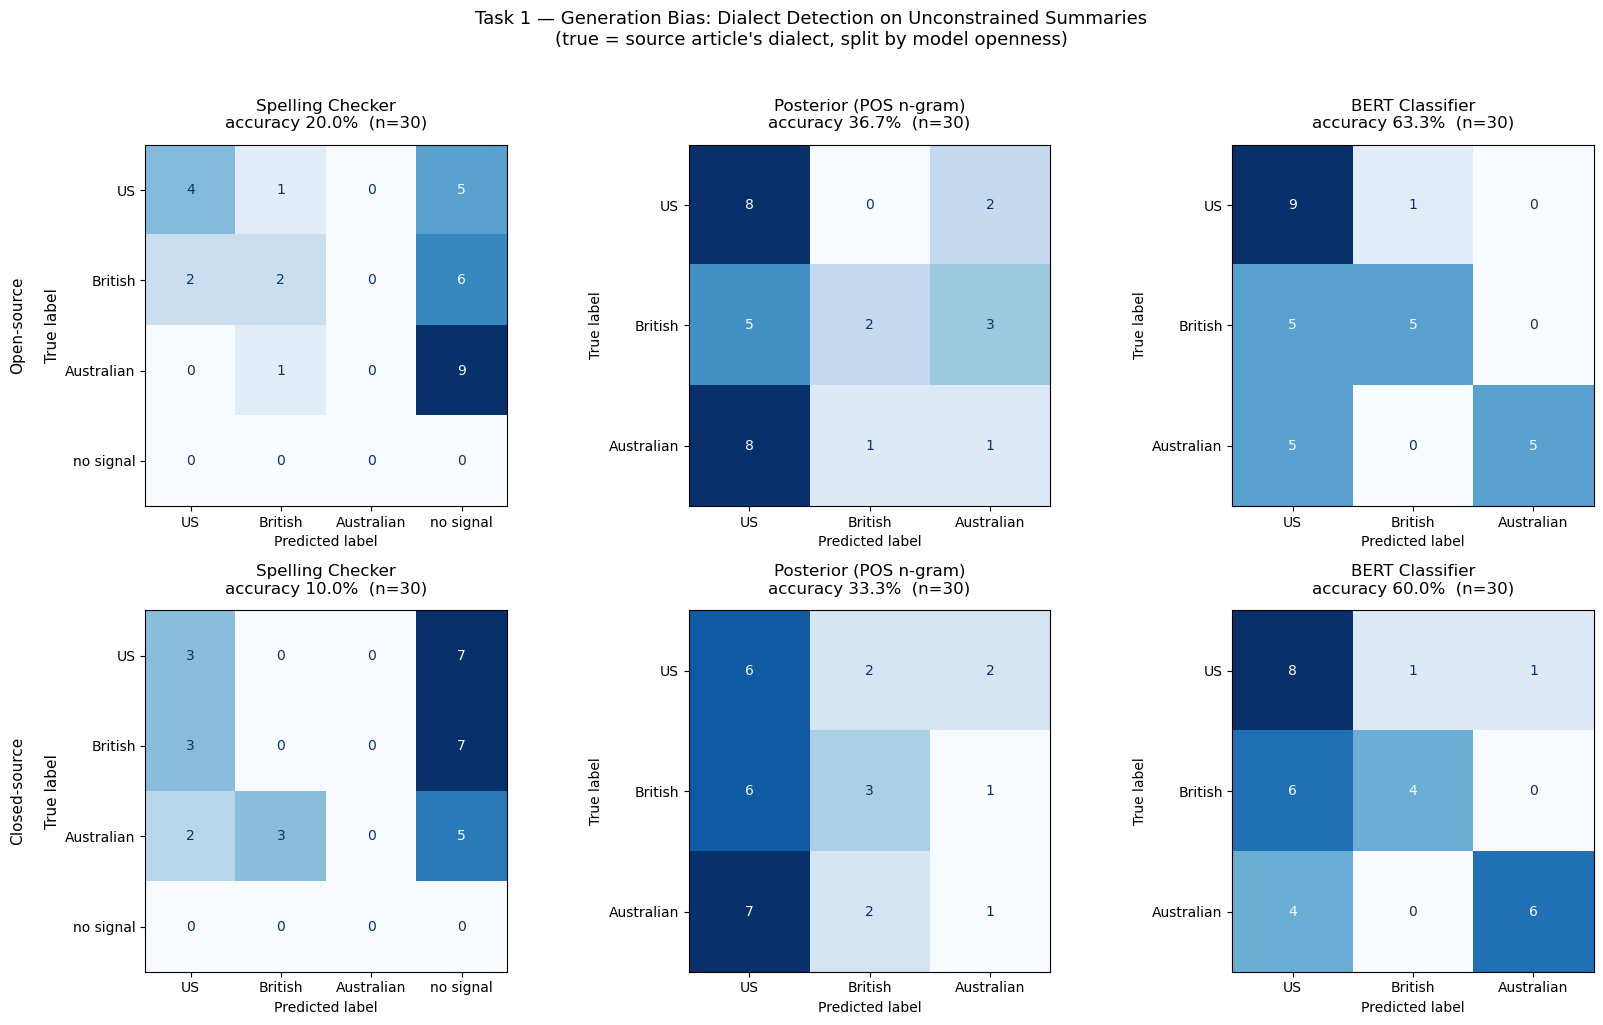

In [179]:
spelling_labels = DIALECTS + ["no signal"]
classifiers = [("spelling", "Spelling Checker", spelling_labels),
               ("pos_ngram", "Posterior (POS n-gram)", DIALECTS),
               ("bert", "BERT Classifier", DIALECTS)]

df_t1_kind = df_t1.assign(kind=df_t1["model"].map(MODEL_KIND).fillna(df_t1["model"]))

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for row, kind in enumerate(MODEL_KIND_ORDER):
    sub = df_t1_kind[df_t1_kind["kind"] == kind]
    for col, (pred_col, title, cm_labels) in enumerate(classifiers):
        ax = axes[row, col]
        if sub.empty:
            ax.set_title(f"{title}\n(no data yet)")
            ax.axis("off")
            continue
        acc = (sub[pred_col] == sub["true"]).mean()
        cm = confusion_matrix(sub["true"], sub[pred_col], labels=cm_labels)
        disp_labels = [DIALECT_DISPLAY.get(l, l) for l in cm_labels]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=disp_labels)
        disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
        ax.set_title(f"{title}\naccuracy {acc:.1%}  (n={len(sub)})", pad=12)
    axes[row, 0].set_ylabel(f"{kind}\n\nTrue label", fontsize=11)

plt.suptitle(
    "Task 1 — Generation Bias: Dialect Detection on Unconstrained Summaries\n"
    "(true = source article's dialect, split by model openness)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

## Task 1 — Predicted Dialect Counts by True Article Dialect

A complementary view to the confusion matrices above: one bar chart per **classifier**
(Spelling / POS n-gram / BERT), x-axis grouped by the summary's **true article dialect**
(US / UK / AUS), bars color-coded by **predicted dialect** and labeled directly above each bar
with that predicted dialect's name (no legend needed, no need to cross-reference colors). Where
the confusion matrices show accuracy, this makes generation bias itself directly visible — e.g.
a tall bar labeled "US" sitting under the "UK" or "AUS" x-tick is concrete evidence of drift
toward American English regardless of source, the exact question Task 1 is asking. Split into
two **separate figures**, one for open-source models and one for closed-source, so a drift
pattern that's really about one model family isn't mistaken for something universal — same split
used for the Task 2 charts above. Spelling can abstain ("no signal") when a summary has zero
dialect-marked words, shown as its own bar/label rather than dropped.

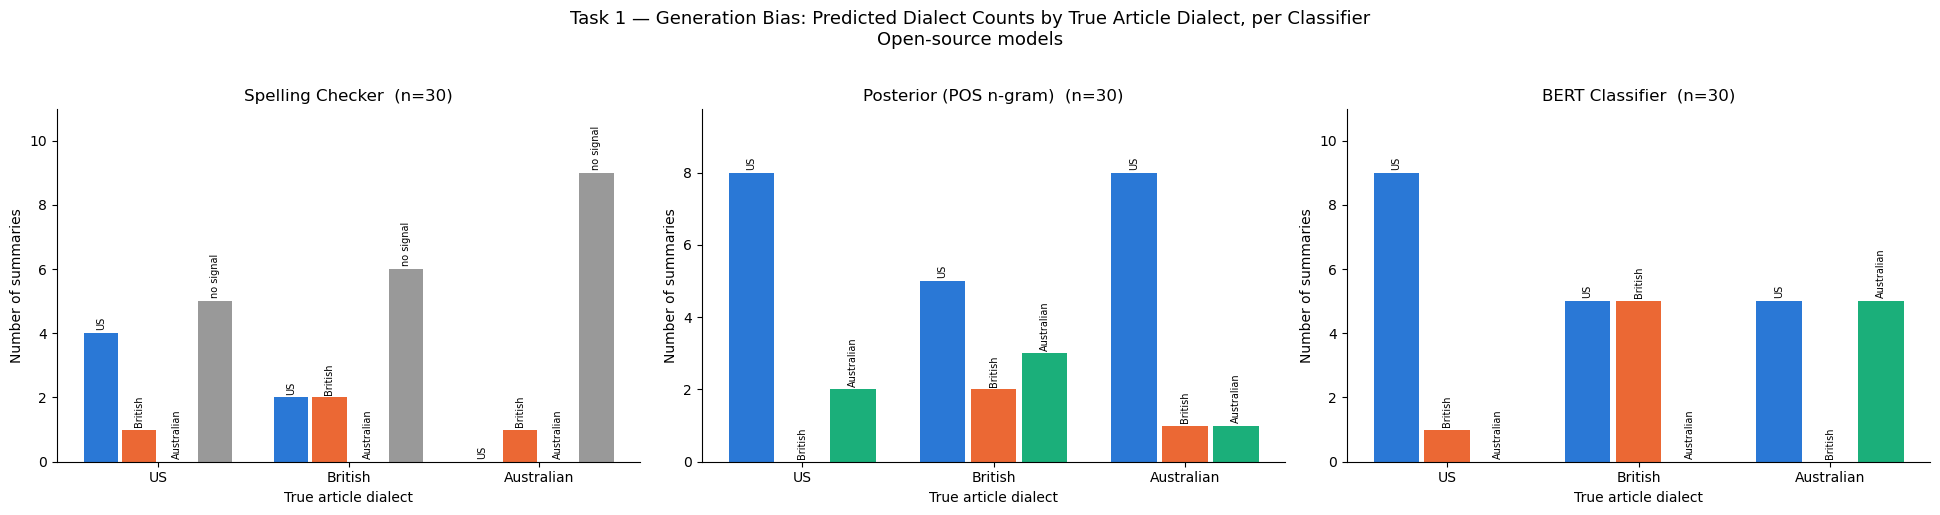

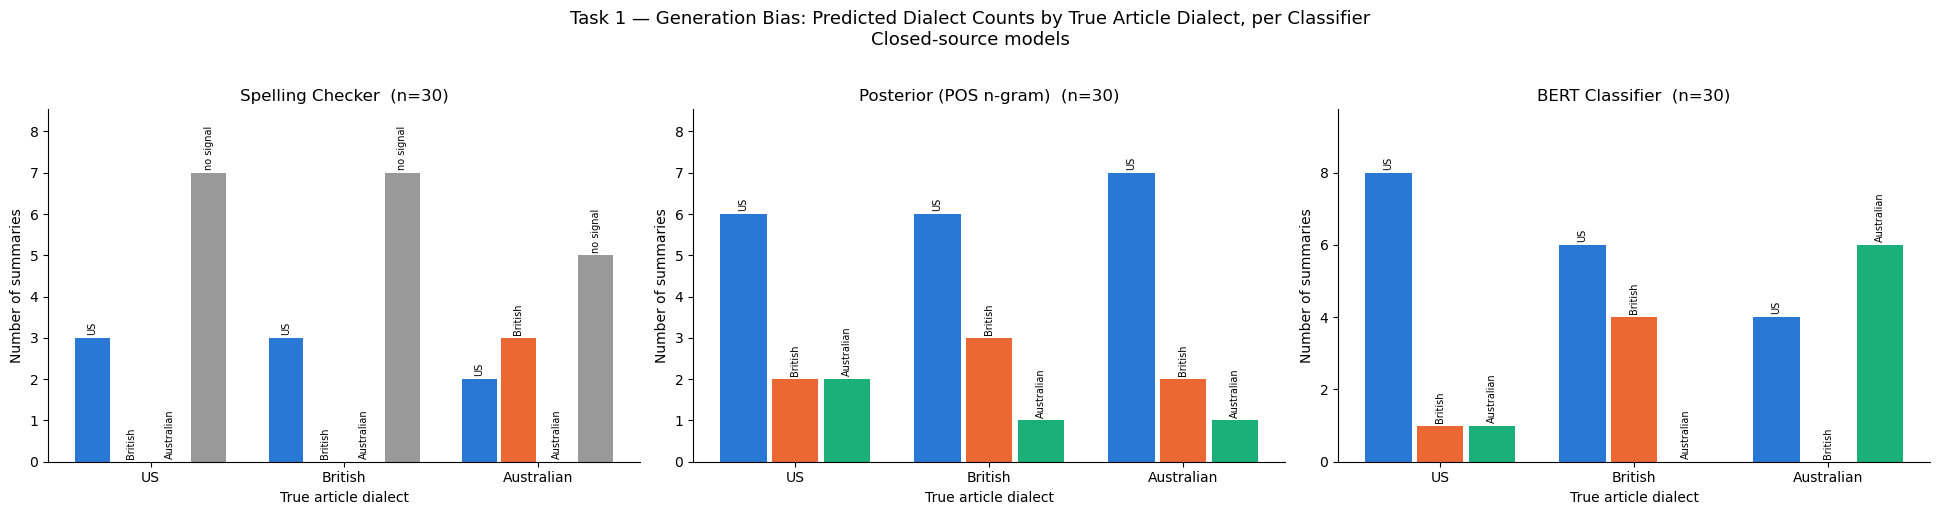

In [180]:
# Predicted-dialect colors — fixed mapping, consistent across all three classifier panels
PRED_DIALECT_COLORS = {"US": "#2a78d6", "UK": "#eb6834", "AUS": "#1baf7a", "no signal": "#999999"}

CLASSIFIER_COLS = [("spelling", "Spelling Checker"),
                    ("pos_ngram", "Posterior (POS n-gram)"),
                    ("bert", "BERT Classifier")]

if df_t1.empty:
    print("No Task 1 summaries yet.")
else:
    df_t1_kind = df_t1.assign(kind=df_t1["model"].map(MODEL_KIND).fillna(df_t1["model"]))

    for kind in MODEL_KIND_ORDER:
        kind_df = df_t1_kind[df_t1_kind["kind"] == kind]

        fig, axes = plt.subplots(1, len(CLASSIFIER_COLS), figsize=(6.5 * len(CLASSIFIER_COLS), 5))

        for ax, (col, label) in zip(axes, CLASSIFIER_COLS):
            if kind_df.empty:
                ax.set_title(f"{label}\n(no data yet)")
                ax.axis("off")
                continue

            pred_labels = DIALECTS + ["no signal"] if col == "spelling" else DIALECTS

            x = np.arange(len(DIALECTS))
            n = len(pred_labels)
            width = 0.8 / n

            for i, pred in enumerate(pred_labels):
                counts = kind_df[kind_df[col] == pred]["true"].value_counts().reindex(DIALECTS, fill_value=0)
                offset = (i - (n - 1) / 2) * width
                bars = ax.bar(x + offset, counts.values, width=width * 0.9, color=PRED_DIALECT_COLORS[pred])
                ax.bar_label(bars, labels=[DIALECT_DISPLAY.get(pred, pred)] * len(bars), padding=2, fontsize=7, rotation=90)

            ax.margins(y=0.22)   # headroom so the rotated above-bar labels don't get clipped
            ax.set_xticks(x)
            ax.set_xticklabels([DIALECT_DISPLAY[d] for d in DIALECTS])
            ax.set_xlabel("True article dialect")
            ax.set_ylabel("Number of summaries")
            ax.set_title(f"{label}  (n={len(kind_df)})")
            ax.spines[["top", "right"]].set_visible(False)

        plt.suptitle(
            "Task 1 — Generation Bias: Predicted Dialect Counts by True Article Dialect, per Classifier\n"
            f"{kind} models",
            fontsize=13, y=1.02,
        )
        plt.tight_layout()
        plt.show()

## Save Predictions to CSV

In [181]:
csv_t1 = SUMMARIES_DIR / "eval_task1_predictions.csv"
csv_t2 = SUMMARIES_DIR / "eval_task2_predictions.csv"

df_t1.to_csv(csv_t1, index=False, encoding="utf-8")
df_t2.to_csv(csv_t2, index=False, encoding="utf-8")

print(f"Saved: {csv_t1}  ({len(df_t1)} rows)")
print(f"Saved: {csv_t2}  ({len(df_t2)} rows)")

Saved: summaries/eval_task1_predictions.csv  (60 rows)
Saved: summaries/eval_task2_predictions.csv  (180 rows)


## BARTScore — Reference-Free Summary Quality (Yuan et al., 2021)

The primary automated quality metric for Task 2, alongside SummaC and the LLM judge below —
different mechanisms, so where they agree is more trustworthy and where they disagree is
informative in its own right.

**What it measures**: the log-likelihood of a BART model (`facebook/bart-large-cnn`, already
fine-tuned for news summarization) generating the *summary* given the *article* as input. Higher
(less negative) means the summary reads like something a competent summarizer would actually
produce from that source — a blend of faithfulness and fluency, reference-free (no human
reference summary needed, article is the reference).

In [88]:
import torch
import torch.nn as nn
from transformers import BartTokenizer, BartForConditionalGeneration

# Adapted directly from https://github.com/neulab/BARTScore/blob/main/bart_score.py
# (Yuan, Neubig & Liu, 2021) — a script, not a pinned package, see markdown above for why
# that matters here.

BARTSCORE_CHECKPOINT = "facebook/bart-large-cnn"  # already fine-tuned for news summarization
BARTSCORE_MAX_LENGTH = 1024
BARTSCORE_BATCH_SIZE = 4

_bart_device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Loading {BARTSCORE_CHECKPOINT} for BARTScore … (device: {_bart_device})")
_bart_tokenizer = BartTokenizer.from_pretrained(BARTSCORE_CHECKPOINT)
_bart_model = BartForConditionalGeneration.from_pretrained(BARTSCORE_CHECKPOINT)
_bart_model.eval()
_bart_model.to(_bart_device)
_bart_loss_fct = nn.NLLLoss(reduction="none", ignore_index=_bart_model.config.pad_token_id)
_bart_lsm = nn.LogSoftmax(dim=1)
print("BARTScore model ready.")


def _load_original_text(file_path: str) -> str:
    with open(file_path, encoding="utf-8") as f:
        raw = json.load(f)
    return (raw.get("full_text") or raw.get("content_snippet") or raw.get("description") or "").strip()


def bartscore_batch(srcs: list[str], tgts: list[str], batch_size: int = BARTSCORE_BATCH_SIZE) -> list[float]:
    """
    For each (source, target) pair, the average per-token log-likelihood of the model
    generating `target` given `source` as input. Higher (less negative) = the summary reads
    like something a good summarizer would actually produce from that source. Reference-free:
    no human reference summary needed, matching this project's setup.
    """
    scores = []
    for i in range(0, len(srcs), batch_size):
        src_batch = srcs[i : i + batch_size]
        tgt_batch = tgts[i : i + batch_size]
        with torch.no_grad():
            encoded_src = _bart_tokenizer(
                src_batch, max_length=BARTSCORE_MAX_LENGTH, truncation=True, padding=True, return_tensors="pt"
            )
            encoded_tgt = _bart_tokenizer(
                tgt_batch, max_length=BARTSCORE_MAX_LENGTH, truncation=True, padding=True, return_tensors="pt"
            )

            src_ids = encoded_src["input_ids"].to(_bart_device)
            src_mask = encoded_src["attention_mask"].to(_bart_device)
            tgt_ids = encoded_tgt["input_ids"].to(_bart_device)
            tgt_mask = encoded_tgt["attention_mask"]
            tgt_len = tgt_mask.sum(dim=1).to(_bart_device)

            output = _bart_model(input_ids=src_ids, attention_mask=src_mask, labels=tgt_ids)
            logits = output.logits.view(-1, _bart_model.config.vocab_size)
            loss = _bart_loss_fct(_bart_lsm(logits), tgt_ids.view(-1))
            loss = loss.view(tgt_ids.shape[0], -1)
            loss = loss.sum(dim=1) / tgt_len
            scores += [-x.item() for x in loss]
    return scores


def compute_bartscore(rows: list[dict]) -> pd.DataFrame:
    if not rows:
        return pd.DataFrame()

    records = []
    for batch_start in range(0, len(rows), BARTSCORE_BATCH_SIZE):
        batch = rows[batch_start : batch_start + BARTSCORE_BATCH_SIZE]
        srcs = [_load_original_text(r["file"]) for r in batch]
        tgts = [r["summary"] for r in batch]
        scores = bartscore_batch(srcs, tgts)

        for row, s in zip(batch, scores):
            records.append({
                "model":           row.get("model", "?"),
                "topic":           row.get("topic", "?"),
                "article_dialect": row.get("article_dialect", "?"),
                "target_dialect":  row.get("target_dialect"),
                "bartscore":       round(s, 4),
            })
        print(f"  scored {min(batch_start + BARTSCORE_BATCH_SIZE, len(rows))}/{len(rows)}")

    return pd.DataFrame(records)


print("Computing BARTScore for Task 2 (constrained) …")
bts_t2 = compute_bartscore(task2)

print(f"\nTask 2 scored: {len(bts_t2)}")

Loading facebook/bart-large-cnn for BARTScore … (device: mps)
BARTScore model ready.
Computing BARTScore for Task 2 (constrained) …
  scored 4/152
  scored 8/152
  scored 12/152
  scored 16/152
  scored 20/152
  scored 24/152
  scored 28/152
  scored 32/152
  scored 36/152
  scored 40/152
  scored 44/152
  scored 48/152
  scored 52/152
  scored 56/152
  scored 60/152
  scored 64/152
  scored 68/152
  scored 72/152
  scored 76/152
  scored 80/152
  scored 84/152
  scored 88/152
  scored 92/152
  scored 96/152
  scored 100/152
  scored 104/152
  scored 108/152
  scored 112/152
  scored 116/152
  scored 120/152
  scored 124/152
  scored 128/152
  scored 132/152
  scored 136/152
  scored 140/152
  scored 144/152
  scored 148/152
  scored 152/152

Task 2 scored: 152


In [89]:
if not bts_t2.empty:
    print("Task 2 — mean BARTScore by model × target_dialect:")
    print(bts_t2.groupby(["model", "target_dialect"])["bartscore"].mean().unstack(fill_value=float("nan")).round(4).to_string())
else:
    print("No Task 2 summaries yet.")

Task 2 — mean BARTScore by model × target_dialect:
target_dialect     AUS      UK      US
model                                 
gemini         -2.2671 -2.3147 -2.1884
gpt_oss        -3.6344 -4.2020 -3.3510


In [90]:
bts_csv_t2 = SUMMARIES_DIR / "bartscore_task2.csv"

bts_t2.to_csv(bts_csv_t2, index=False)

print(f"Saved: {bts_csv_t2}  ({len(bts_t2)} rows)")

Saved: summaries/bartscore_task2.csv  (152 rows)


## SummaC — Factual Consistency, Task 2 Only (Laban et al., 2022)

A second, independent quality signal alongside BARTScore above and the LLM judge below — measures
something more specific than general "quality": whether the summary is factually **entailed** by
the source article, sentence by sentence. Uses `SummaCConv` — an NLI model (`vitc`, ALBERT-xlarge
fine-tuned on VitaminC+MNLI) scores every (article-sentence, summary-sentence) pair for
entailment, and a small trained aggregation head turns that grid into a single P(consistent)
∈ [0, 1] for the whole summary. Higher = the summary's claims are better supported by the article;
unlike BARTScore (fluency/likelihood), a summary can read fluently and stay on-topic while still
asserting something the article never said — that's specifically what this catches.


In [ ]:
# %pip install --no-deps summac   # plain `pip install summac` downgrades transformers/huggingface-hub, see markdown above
from summac.model_summac import SummaCConv

SUMMAC_MODEL_NAME = "vitc"          # ALBERT-xlarge fine-tuned on VitaminC+MNLI, matches the paper's top single-model config
SUMMAC_GRANULARITY = "sentence"

print(f"Loading SummaCConv ({SUMMAC_MODEL_NAME}) … (device: {_bart_device})")
summac_model = SummaCConv(
    models=[SUMMAC_MODEL_NAME],
    bins="percentile",
    granularity=SUMMAC_GRANULARITY,
    nli_labels="e",
    device=_bart_device,
    start_file="default",
    agg="mean",
)
print("SummaC model ready.")


def compute_summac(rows: list[dict]) -> pd.DataFrame:
    if not rows:
        return pd.DataFrame()

    records = []
    for i, row in enumerate(rows, start=1):
        original = _load_original_text(row["file"])
        summary = row["summary"]
        result = summac_model.score([original], [summary])

        records.append({
            "model":          row.get("model", "?"),
            "topic":          row.get("topic", "?"),
            "target_dialect": row.get("target_dialect"),
            "summac":         round(result["scores"][0], 4),
        })
        if i % 10 == 0 or i == len(rows):
            print(f"  scored {i}/{len(rows)}")

    return pd.DataFrame(records)


print("Computing SummaC for Task 2 (constrained) …")
summac_t2 = compute_summac(task2)

print(f"\nTask 2 scored: {len(summac_t2)}")

Loading SummaCConv (vitc) … (device: mps)
<All keys matched successfully>


/opt/anaconda3/lib/python3.12/site-packages/summac/model_summac.py:250: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  print(self.load_state_dict(torch.load(start_file)))


SummaC model ready.
Computing SummaC for Task 2 (constrained) …
  scored 10/152
  scored 20/152
  scored 30/152
  scored 40/152
  scored 50/152
  scored 60/152


In [ ]:
if not summac_t2.empty:
    print("Task 2 — mean SummaC (P consistent) by model × target_dialect:")
    print(summac_t2.groupby(["model", "target_dialect"])["summac"].mean().unstack(fill_value=float("nan")).round(4).to_string())
else:
    print("No Task 2 summaries yet.")

In [ ]:
summac_csv_t2 = SUMMARIES_DIR / "summac_task2.csv"

summac_t2.to_csv(summac_csv_t2, index=False)

print(f"Saved: {summac_csv_t2}  ({len(summac_t2)} rows)")

## LLM-as-a-Judge — Quality Scoring

Each summary is rated 1–10 by a judge LLM for accuracy/completeness/concision relative to its
original article — the third Task 2 quality signal alongside BARTScore and SummaC above, used
together because each has a different blind spot: BARTScore/SummaC can't quantify overall
"quality" the way a judge's holistic score can, and the judge can't quantify factual entailment
as precisely as SummaC does.

**Caveats:**
- *Judge dialect bias* — the judge may itself favor American-English phrasing when scoring
  quality, which is exactly the bias this whole project investigates. That's why the judge score
  is reported alongside, not instead of, BARTScore, SummaC, and the dialect-detection classifiers.
- *Self-preference bias* — `gpt_oss` judging `gpt_oss`-written summaries (or Gemini judging its
  own) is a known confound in LLM-as-judge setups. `JUDGE_MODEL` below defaults to **`gpt_oss`**
  — if you want a judge that never scores its own outputs, set it to `"gemini"` instead, or read
  the two judges' scores as a pair rather than trusting either in isolation.
- *Both providers have a real daily cap, confirmed empirically, not just "generous"*: Gemini's
  free tier here is capped at 20 **requests**/day. Groq's `openai/gpt-oss-120b` is capped at
  200,000 **tokens**/day (confirmed via a live 429 `rate_limit_exceeded` response) — easy to hit
  given generation (Task 1 + Task 2, ~150+ calls with full-article prompts) already consumes a
  large share of that budget before judging even starts. Both are handled the same way as in
  `make_ai_summaries.ipynb`: a real quota error stops that model for the rest of the run without
  wasting retries, and the JSONL checkpoint means re-running tomorrow picks up where it left off.
- *Task 2 only* — this section only judges `task2` now (dropped Task 1 judging to cut runtime,
  since Task 1's own results section relies on the dialect classifiers, not this judge score).

In [ ]:
import re
import time

# ── API Keys — fill in before running (reuse the same keys from make_ai_summaries.ipynb) ──
GEMINI_API_KEY = "AQ.Ab8RN6L--t1NYVPhP0eX1MbI685_TFBkbyFIW2mAzcrkoO_ZOQ"   # aistudio.google.com/app/apikey
GROQ_API_KEY   = "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"     # console.groq.com/keys

# ── Judge model ────────────────────────────────────────────────────────────
JUDGE_MODEL = "gpt_oss"   # "gpt_oss" (Groq, 200K tokens/day) or "gemini" (20 requests/day here)
GEMINI_MODEL = "gemini-2.5-flash"
OPEN_MODEL   = "openai/gpt-oss-120b"

JUDGE_PATH_T2 = SUMMARIES_DIR / "judge_task2.jsonl"
JUDGE_DELAY   = 1.5

from google import genai
from google.genai import types as genai_types
from groq import Groq

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
groq_client   = Groq(api_key=GROQ_API_KEY)

print(f"Judge model: {JUDGE_MODEL}")

In [ ]:
class QuotaExceededError(Exception):
    """A provider's free-tier quota is exhausted for now — not worth retrying immediately."""
    pass


def _is_quota_error(exc: Exception) -> bool:
    status = getattr(exc, "status_code", None) or getattr(exc, "code", None)
    if status == 429:
        return True
    msg = str(exc).lower()
    return any(s in msg for s in ("429", "resource_exhausted", "rate_limit_exceeded", "quota"))


def call_with_retry(fn, max_retries: int = 3, base_delay: float = 5.0):
    for attempt in range(max_retries):
        try:
            return fn()
        except QuotaExceededError:
            raise
        except Exception as exc:
            if attempt == max_retries - 1:
                raise
            delay = base_delay * (2 ** attempt)
            print(f"    [retry {attempt+1}/{max_retries} in {delay:.0f}s] {exc}")
            time.sleep(delay)


def _call_gemini(prompt: str) -> str:
    def _call():
        try:
            resp = gemini_client.models.generate_content(
                model=GEMINI_MODEL,
                contents=prompt,
                config=genai_types.GenerateContentConfig(
                    max_output_tokens=512,
                    temperature=0.0,
                    # gemini-2.5-flash "thinks" by default and draws thinking tokens from the
                    # SAME max_output_tokens budget — confirmed directly (make_ai_summaries.ipynb)
                    # that this can eat nearly the whole budget and truncate the answer before it
                    # completes (one live call: 487/512 tokens spent thinking, answer cut off
                    # mid-sentence, finish_reason=MAX_TOKENS). Critical here since the judge's
                    # answer must be complete, parseable JSON.
                    thinking_config=genai_types.ThinkingConfig(thinking_budget=0),
                ),
            )
        except Exception as exc:
            if _is_quota_error(exc):
                raise QuotaExceededError(str(exc)) from exc
            raise
        return resp.text.strip()
    return call_with_retry(_call)


def _call_groq(prompt: str) -> str:
    def _call():
        try:
            resp = groq_client.chat.completions.create(
                model=OPEN_MODEL,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=512,
                temperature=0.0,
                reasoning_effort="low",   # gpt-oss is a reasoning model — without this it can
                                          # spend the whole token budget on a hidden reasoning
                                          # trace and get cut off before emitting the JSON at all
            )
        except Exception as exc:
            if _is_quota_error(exc):
                raise QuotaExceededError(str(exc)) from exc
            raise
        return resp.choices[0].message.content.strip()
    return call_with_retry(_call)


JUDGE_CALL = {"gemini": _call_gemini, "gpt_oss": _call_groq}[JUDGE_MODEL]

JUDGE_PROMPT = (
    "You are an expert evaluator of news article summaries.\n\n"
    "Rate the following summary on a scale from 1 to 10, where:\n"
    "  10 = perfect: accurate, complete, concise, no hallucinations\n"
    "   7 = good: mostly accurate, minor omissions\n"
    "   4 = fair: captures main idea but notable gaps or inaccuracies\n"
    "   1 = poor: inaccurate, incoherent, or off-topic\n\n"
    "Original article:\n{article}\n\n"
    "Summary to evaluate:\n{summary}\n\n"
    "Respond ONLY with valid JSON on a single line, like:\n"
    '{{"score": <1-10>, "reasoning": "<one sentence>"}}'
)


def judge_summary(article_text: str, summary: str) -> dict:
    prompt = JUDGE_PROMPT.format(article=article_text[:3000], summary=summary)
    raw = JUDGE_CALL(prompt)
    raw = raw.strip().lstrip("```json").rstrip("`").strip()
    match = re.search(r'\{.*\}', raw, re.DOTALL)
    if not match:
        raise ValueError(f"Could not parse judge response: {raw[:120]}")
    return json.loads(match.group())


print("Judge functions ready.")

Judge functions ready.


In [ ]:
quota_exhausted_judge = False


def run_judge(rows: list[dict], path) -> pd.DataFrame:
    global quota_exhausted_judge

    existing = load_jsonl(path)
    done = {(r["file"], r["model"]) for r in existing}
    todo = [r for r in rows if (r["file"], r["model"]) not in done]
    print(f"  already done: {len(existing)}   remaining: {len(todo)}")

    errors = []
    for row in todo:
        if quota_exhausted_judge:
            break
        article_text = _load_original_text(row["file"])
        try:
            result = judge_summary(article_text, row["summary"])
            record = {
                "file":            row["file"],
                "model":           row["model"],
                "topic":           row.get("topic", "?"),
                "article_dialect": row.get("article_dialect", "?"),
                "target_dialect":  row.get("target_dialect"),
                "score":           result["score"],
                "reasoning":       result.get("reasoning", ""),
            }
            with open(path, "a", encoding="utf-8") as f:
                f.write(json.dumps(record, ensure_ascii=False) + "\n")
        except QuotaExceededError:
            quota_exhausted_judge = True
            print(f"  ⚠️  {JUDGE_MODEL}: quota exhausted — stopping judge run here. Re-run later to resume.")
        except Exception as exc:
            errors.append({"file": row["file"], "model": row["model"], "error": str(exc)})
            print(f"  ERROR judging {row['file']}: {exc}")
        time.sleep(JUDGE_DELAY)

    if errors:
        print(f"  {len(errors)} parse/API errors — see returned list")
    return pd.DataFrame(load_jsonl(path)), errors


print("Judging Task 2 (constrained) …")
df_judge_t2, judge_errors_t2 = run_judge(task2, JUDGE_PATH_T2)

print(f"\nTask 2 judged: {len(df_judge_t2)}")

In [ ]:
if not df_judge_t2.empty:
    print("Task 2 — mean judge score (1-10) by model × target_dialect:")
    print(df_judge_t2.groupby(["model", "target_dialect"])["score"].mean().unstack(fill_value=float("nan")).round(2).to_string())
else:
    print("No Task 2 judge scores yet.")

In [ ]:
judge_csv_t2 = SUMMARIES_DIR / "judge_task2.csv"

df_judge_t2.to_csv(judge_csv_t2, index=False)

print(f"Saved: {judge_csv_t2}  ({len(df_judge_t2)} rows)")

## Task 2 — Summary Table

Collates the three Task 2 quality metrics into one table before the bar charts below — the
charts show relative magnitude at a glance, this gives the exact numbers for the report. Split
into two separate tables, one per model kind (open-source / closed-source), each with columns =
target dialect (US / UK / AUS) and rows = metric (Type/Model columns dropped from the display
since each table is already scoped to one kind). Both **mean** and **standard deviation** are
shown per (model, metric, dialect) — the mean tables answer "which is better", the std-dev tables
answer "which is more consistent" (a low mean with low spread is a more reliable weak spot than
one dragged down by a couple of outliers).

Reads directly from the saved CSVs (`bartscore_task2.csv`, `summac_task2.csv`, `judge_task2.csv`)
rather than the in-memory dataframes from the cells above, so this table can be regenerated any
time — after re-running the judge later to pick up more rows, for example — without re-running
the slow BARTScore/SummaC compute cells just to refresh a table.

In [182]:
def _load_metric_stats(filename: str, value_col: str) -> pd.DataFrame:
    """Returns a (model, target_dialect)-indexed DataFrame with 'mean' and 'std' columns."""
    path = SUMMARIES_DIR / filename
    if not path.exists():
        return pd.DataFrame(columns=["mean", "std"])
    df = pd.read_csv(path)
    if df.empty:
        return pd.DataFrame(columns=["mean", "std"])
    return df.groupby(["model", "target_dialect"])[value_col].agg(["mean", "std"])


METRIC_STATS = [
    ("LLM-as-a-Judge", _load_metric_stats("judge_task2.csv", "score")),
    ("BARTScore",      _load_metric_stats("bartscore_task2.csv", "bartscore")),
    ("SummaC",         _load_metric_stats("summac_task2.csv", "summac")),
]

if all(stats.empty for _, stats in METRIC_STATS):
    print("No Task 2 metric CSVs found yet — run the BARTScore / SummaC / Judge cells above at least once.")
else:
    def _kind_index(model: str) -> int:
        kind = MODEL_KIND.get(model, model)
        return MODEL_KIND_ORDER.index(kind) if kind in MODEL_KIND_ORDER else len(MODEL_KIND_ORDER)

    models_present = sorted(
        {model for _, stats in METRIC_STATS for model, _ in stats.index},
        key=lambda m: (_kind_index(m), m),
    )

    def _build_long(stat_col: str) -> pd.DataFrame:
        rows = []
        for model in models_present:
            for metric_name, stats in METRIC_STATS:
                row = {"Type": MODEL_KIND.get(model, model), "Model": model, "Metric": metric_name}
                for dialect in DIALECTS:
                    try:
                        row[dialect] = stats.loc[(model, dialect), stat_col]
                    except KeyError:
                        row[dialect] = float("nan")
                rows.append(row)
        return pd.DataFrame(rows).round(4)

    # Full long-format tables (kept for the saved CSVs — include Type/Model for completeness)
    metrics_table_t2 = _build_long("mean")
    metrics_std_t2 = _build_long("std")

    metrics_summary_csv = SUMMARIES_DIR / "task2_metrics_summary.csv"
    metrics_table_t2.to_csv(metrics_summary_csv, index=False)
    metrics_std_csv = SUMMARIES_DIR / "task2_metrics_std.csv"
    metrics_std_t2.to_csv(metrics_std_csv, index=False)
    print(f"Saved: {metrics_summary_csv}  ({len(metrics_table_t2)} rows)")
    print(f"Saved: {metrics_std_csv}  ({len(metrics_std_t2)} rows)\n")

    # Per-kind display tables — Type/Model dropped since each table is already scoped to one
    # kind (the print label above it says which).
    for kind in MODEL_KIND_ORDER:
        kind_models = [m for m in models_present if MODEL_KIND.get(m, m) == kind]
        if not kind_models:
            continue
        model_label = ", ".join(kind_models)

        mean_table = metrics_table_t2[metrics_table_t2["Model"].isin(kind_models)].drop(columns=["Type", "Model"]).reset_index(drop=True)
        std_table = metrics_std_t2[metrics_std_t2["Model"].isin(kind_models)].drop(columns=["Type", "Model"]).reset_index(drop=True)

        print(f"{kind} ({model_label}) — mean:")
        display(mean_table)
        print(f"{kind} ({model_label}) — std dev (NaN = fewer than 2 summaries for that cell):")
        display(std_table)
        print()

Saved: summaries/task2_metrics_summary.csv  (6 rows)
Saved: summaries/task2_metrics_std.csv  (6 rows)

Open-source (gpt_oss) — mean:


,Metric,US,UK,AUS
0,LLM-as-a-Judge,5.9000,3.8929,4.8519
1,BARTScore,-3.3510,-4.2020,-3.6344
2,SummaC,0.2804,0.2659,0.2711


Open-source (gpt_oss) — std dev (NaN = fewer than 2 summaries for that cell):


,Metric,US,UK,AUS
0,LLM-as-a-Judge,3.0439,2.9732,2.9313
1,BARTScore,1.5600,1.8531,1.6615
2,SummaC,0.1361,0.1280,0.0866



Closed-source (gemini) — mean:


,Metric,US,UK,AUS
0,LLM-as-a-Judge,6.6667,6.6333,6.7857
1,BARTScore,-2.1517,-2.2715,-2.1833
2,SummaC,0.3140,0.3143,0.3213


Closed-source (gemini) — std dev (NaN = fewer than 2 summaries for that cell):


,Metric,US,UK,AUS
0,LLM-as-a-Judge,1.9885,1.7905,1.8531
1,BARTScore,0.3901,0.4189,0.4674
2,SummaC,0.0848,0.0800,0.0966


## Task 2 Results — Evaluation Bias

When a model is explicitly instructed to write in a given dialect (`target_dialect`), does the
*quality* of the summary it produces differ by dialect? A systematic drop for one dialect would
mean the model (or, for the judge score, the evaluator itself) is worse at — or biased against —
producing/scoring that dialect. Shown across the three quality metrics computed above, as mean
value per target dialect on the Task 2 (constrained) summaries:

- **LLM-as-a-Judge** — mean 1–10 quality score.
- **BARTScore** — mean log-likelihood of the summary given the article (higher = better).
- **SummaC** — mean P(consistent), factual entailment with the source article (higher = better).

Split into two rows — **open-source** (`gpt_oss`) vs **closed-source** (`gemini`) — so a quality
gap that's really about one model family isn't mistaken for a dialect effect.

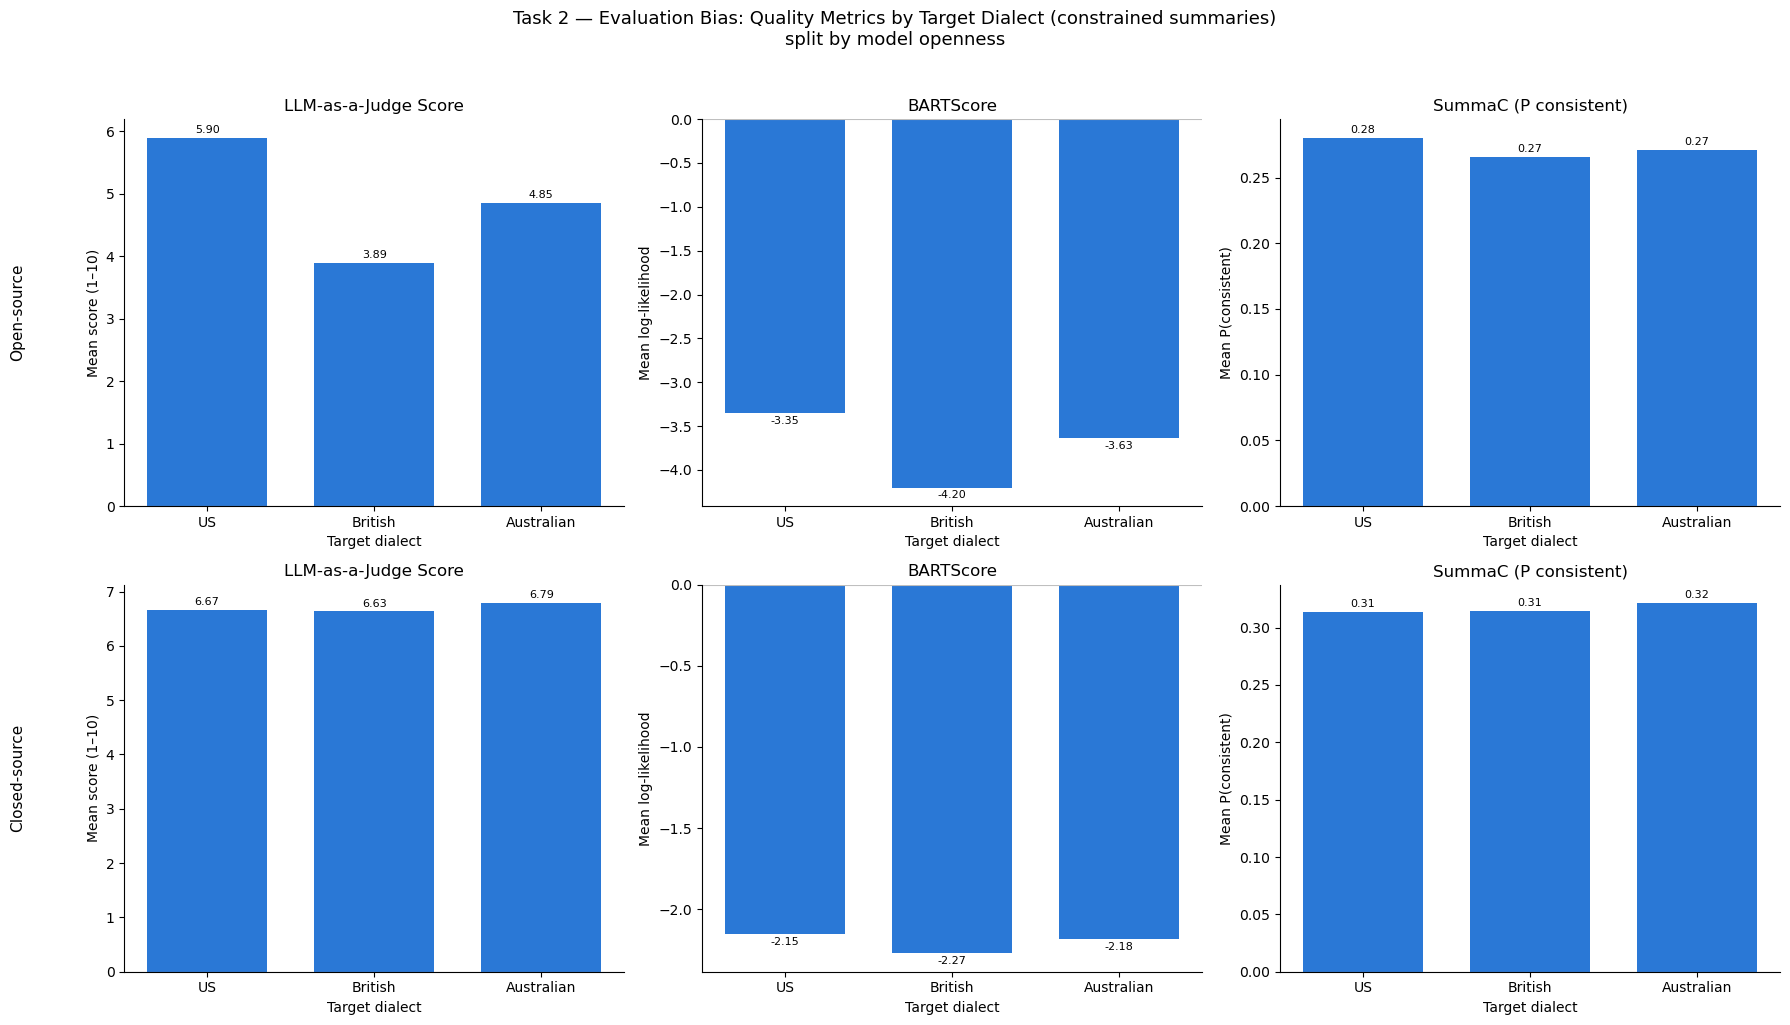

In [183]:
# Categorical palette, fixed order (blue, orange, aqua, yellow) — assigned by model, never cycled
MODEL_PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]


def bar_by_dialect(ax, df: pd.DataFrame, value_col: str, title: str, ylabel: str) -> None:
    if df.empty:
        ax.set_title(f"{title}\n(no data yet)")
        ax.axis("off")
        return

    pivot = df.groupby(["target_dialect", "model"])[value_col].mean().unstack("model")
    pivot = pivot.reindex(DIALECTS)
    models = list(pivot.columns)
    colors = dict(zip(models, MODEL_PALETTE))

    x = np.arange(len(pivot.index))
    n_models = len(models)
    width = 0.8 / n_models

    for i, model in enumerate(models):
        offset = (i - (n_models - 1) / 2) * width
        bars = ax.bar(x + offset, pivot[model].values, width=width * 0.9,
                       label=model, color=colors[model])
        ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([DIALECT_DISPLAY.get(d, d) for d in pivot.index])
    ax.set_xlabel("Target dialect")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    ax.axhline(0, color="0.75", linewidth=0.8)
    if n_models > 1:
        ax.legend(title="Model", frameon=False, fontsize=8)


METRICS_T2 = [(df_judge_t2, "score", "LLM-as-a-Judge Score", "Mean score (1–10)"),
              (bts_t2,      "bartscore", "BARTScore", "Mean log-likelihood"),
              (summac_t2,   "summac", "SummaC (P consistent)", "Mean P(consistent)")]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, kind in enumerate(MODEL_KIND_ORDER):
    kind_models = [m for m, k in MODEL_KIND.items() if k == kind]
    for col, (df, value_col, title, ylabel) in enumerate(METRICS_T2):
        sub = df[df["model"].isin(kind_models)] if not df.empty else df
        bar_by_dialect(axes[row, col], sub, value_col, title, ylabel)
    axes[row, 0].annotate(kind, xy=(0, 0.5), xytext=(-axes[row, 0].yaxis.labelpad - 40, 0),
                           xycoords=axes[row, 0].yaxis.label, textcoords="offset points",
                           size=11, ha="right", va="center", rotation=90)

plt.suptitle(
    "Task 2 — Evaluation Bias: Quality Metrics by Target Dialect (constrained summaries)\n"
    "split by model openness",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

## Task 2 — Per-Metric Bar Charts (US / UK / AUS)

One chart per Task 2 quality metric — LLM-as-a-Judge, BARTScore, SummaC — each showing all three
target dialects side by side, bars color-coded by model. Split into two **separate figures**, one
for open-source models and one for closed-source, so a quality gap that's really about one model
family isn't mistaken for a dialect effect (same split as the grid above, just rendered as its
own full-width figure per model kind instead of stacked rows). Reuses `bar_by_dialect()` defined
above, so styling (palette, value labels, dialect ordering) stays identical to the earlier chart.

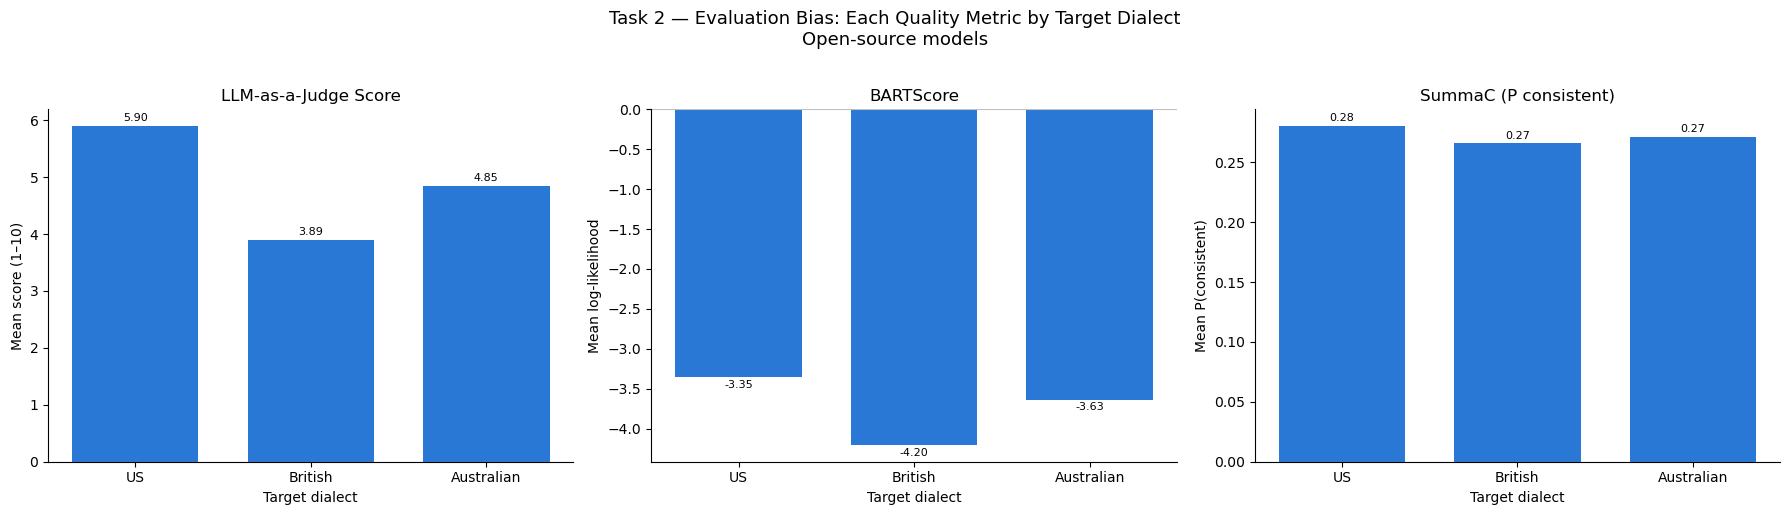

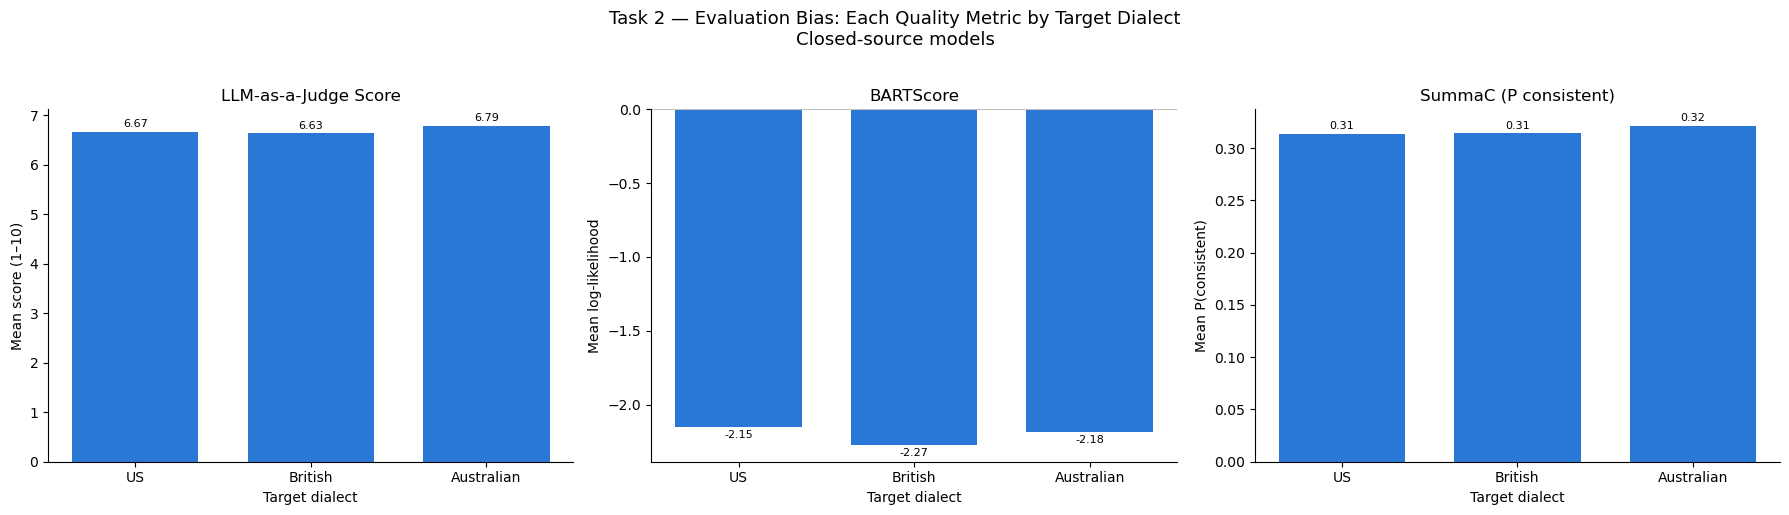

In [184]:
METRICS_T2_ALL = [
    (df_judge_t2, "score",     "LLM-as-a-Judge Score", "Mean score (1–10)"),
    (bts_t2,      "bartscore", "BARTScore",             "Mean log-likelihood"),
    (summac_t2,   "summac",    "SummaC (P consistent)", "Mean P(consistent)"),
]

for kind in MODEL_KIND_ORDER:
    kind_models = [m for m, k in MODEL_KIND.items() if k == kind]

    fig, axes = plt.subplots(1, len(METRICS_T2_ALL), figsize=(6 * len(METRICS_T2_ALL), 5))

    for ax, (df, value_col, title, ylabel) in zip(axes, METRICS_T2_ALL):
        sub = df[df["model"].isin(kind_models)] if not df.empty else df
        bar_by_dialect(ax, sub, value_col, title, ylabel)

    plt.suptitle(
        f"Task 2 — Evaluation Bias: Each Quality Metric by Target Dialect\n{kind} models",
        fontsize=13, y=1.02,
    )
    plt.tight_layout()
    plt.show()

## Dated — BERTScore (unused)

Moved here and disabled: BERTScore was slow (`microsoft/deberta-xlarge-mnli` is large, and it
scores every summary against its full source article) and is superseded for the report by
BARTScore + SummaC + LLM-as-a-Judge above, which now run in its place. Kept here for reference /
easy re-enable — every cell below is commented out and does nothing on a normal run-all.

Original description: measures semantic similarity between each **generated summary**
(hypothesis) and its **original source article** (reference) — there's no human reference
summary, so the article itself is the reference. Higher F1 means the summary stayed semantically
closer to the source.

In [185]:
# %pip install -U bert-score
# from bert_score import score as bert_score_fn
#
# BERTSCORE_MODEL = "microsoft/deberta-xlarge-mnli"
# BERTSCORE_LANG  = "en"
# BERTSCORE_BATCH_SIZE = 16   # deberta-xlarge-mnli is large; unbatched scoring of the full set
#                             # of (summary, article) pairs at once can OOM / kill the kernel
# BERTSCORE_MAX_REF_CHARS = 4000   # articles run long; truncate the reference side for speed/memory
#
#
# def _load_original_text(file_path: str) -> str:
#     with open(file_path, encoding="utf-8") as f:
#         raw = json.load(f)
#     return (raw.get("full_text") or raw.get("content_snippet") or raw.get("description") or "").strip()
#
#
# def compute_bertscore(rows: list[dict]) -> pd.DataFrame:
#     if not rows:
#         return pd.DataFrame()
#
#     records = []
#     for batch_start in range(0, len(rows), BERTSCORE_BATCH_SIZE):
#         batch = rows[batch_start : batch_start + BERTSCORE_BATCH_SIZE]
#         hyps = [r["summary"] for r in batch]
#         refs = [_load_original_text(r["file"])[:BERTSCORE_MAX_REF_CHARS] for r in batch]
#
#         P, R, F1 = bert_score_fn(
#             hyps, refs,
#             model_type=BERTSCORE_MODEL,
#             lang=BERTSCORE_LANG,
#             verbose=False,
#         )
#
#         for row, p, r, f in zip(batch, P.tolist(), R.tolist(), F1.tolist()):
#             records.append({
#                 "model":           row.get("model", "?"),
#                 "topic":           row.get("topic", "?"),
#                 "article_dialect": row.get("article_dialect", "?"),
#                 "target_dialect":  row.get("target_dialect"),   # None for Task 1 (unconstrained)
#                 "precision":       round(p, 4),
#                 "recall":          round(r, 4),
#                 "f1":              round(f, 4),
#             })
#         print(f"  scored {min(batch_start + BERTSCORE_BATCH_SIZE, len(rows))}/{len(rows)}")
#
#     return pd.DataFrame(records)
#
#
# print("Computing BERTScore for Task 1 (unconstrained) …")
# bs_t1 = compute_bertscore(task1)
#
# print("Computing BERTScore for Task 2 (constrained) …")
# bs_t2 = compute_bertscore(task2)
#
# print(f"\nTask 1 scored: {len(bs_t1)}   Task 2 scored: {len(bs_t2)}")

In [186]:
# if not bs_t1.empty:
#     print("Task 1 — mean BERTScore F1 by model × article_dialect:")
#     print(bs_t1.groupby(["model", "article_dialect"])["f1"].mean().unstack(fill_value=float("nan")).round(4).to_string())
# else:
#     print("No Task 1 summaries yet.")
#
# if not bs_t2.empty:
#     print("\nTask 2 — mean BERTScore F1 by model × target_dialect:")
#     print(bs_t2.groupby(["model", "target_dialect"])["f1"].mean().unstack(fill_value=float("nan")).round(4).to_string())
# else:
#     print("No Task 2 summaries yet.")

In [187]:
# bs_csv_t1 = SUMMARIES_DIR / "bertscore_task1.csv"
# bs_csv_t2 = SUMMARIES_DIR / "bertscore_task2.csv"
#
# bs_t1.to_csv(bs_csv_t1, index=False)
# bs_t2.to_csv(bs_csv_t2, index=False)
#
# print(f"Saved: {bs_csv_t1}  ({len(bs_t1)} rows)")
# print(f"Saved: {bs_csv_t2}  ({len(bs_t2)} rows)")